<a href="https://colab.research.google.com/github/allegiova/TinyML/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow==2.0.0-rc1

ERROR: Could not find a version that satisfies the requirement tensorflow==2.0.0-rc1 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.0.0-rc1


# Parse and prepare the data

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# The list of gestures that data is available for
GESTURES = [
   "wave",
   "circle",
   "up_down",
   "punch",
]

SAMPLES_PER_GESTURE = 1
NUM_GESTURES = len(GESTURES)

# Create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

# Read each csv file and push an input and output
for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  # Ensure the file is in the correct directory
  df = pd.read_csv("/content/" + gesture + ".csv")

  # calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)
  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  for i in range(num_recordings):
    tensor = []
    for j in range(SAMPLES_PER_GESTURE):
      index = i * SAMPLES_PER_GESTURE + j

      # Build the tensor with 18 features normalized between 0 and 1
      tensor += [
          # --- ACCELEROMETER (X, Y, Z) ---
          (df['RMS_aX'].iloc[index]) / 4.0,
          (df['Mean_aX'].iloc[index] + 2.0) / 4.0,
          (df['PSDPeak_aX'].iloc[index]) / 15.0,

          (df['RMS_aY'].iloc[index]) / 4.0,
          (df['Mean_aY'].iloc[index] + 4.0) / 8.0,
          (df['PSDPeak_aY'].iloc[index]) / 15.0,

          (df['RMS_aZ'].iloc[index]) / 4.0,
          (df['Mean_aZ'].iloc[index] + 2.0) / 4.0,
          (df['PSDPeak_aZ'].iloc[index]) / 15.0,

          # --- GYROSCOPE (X, Y, Z) ---
          (df['RMS_gX'].iloc[index]) / 2000.0,
          (df['Mean_gX'].iloc[index] + 2000.0) / 4000.0,
          (df['PSDPeak_gX'].iloc[index]) / 15.0,

          (df['RMS_gY'].iloc[index]) / 2000.0,
          (df['Mean_gY'].iloc[index] + 2000.0) / 4000.0,
          (df['PSDPeak_gY'].iloc[index]) / 15.0,

          (df['RMS_gZ'].iloc[index]) / 2000.0,
          (df['Mean_gZ'].iloc[index] + 2000.0) / 4000.0,
          (df['PSDPeak_gZ'].iloc[index]) / 15.0
      ]
    inputs.append(tensor)
    outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Data set parsing and preparation complete.")
print(f"Input shape: {inputs.shape}")

TensorFlow version = 2.19.0

Processing index 0 for gesture 'wave'.
	There are 23 recordings of the wave gesture.
Processing index 1 for gesture 'circle'.
	There are 29 recordings of the circle gesture.
Processing index 2 for gesture 'up_down'.
	There are 23 recordings of the up_down gesture.
Processing index 3 for gesture 'punch'.
	There are 24 recordings of the punch gesture.
Data set parsing and preparation complete.
Input shape: (99, 18)


# Randomize and split the input and output pairs for training

In [4]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


# Build & Train the Model

In [5]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(30, activation='relu')) # relu is used for performance
model.add(tf.keras.layers.Dense(15, activation='relu'))
model.add(tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')) # softmax is used, because we only expect one gesture to occur per input
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(inputs_train, outputs_train, epochs=400, batch_size=1, validation_data=(inputs_validate, outputs_validate))

Epoch 1/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1186 - loss: 1.3894 - val_accuracy: 0.2857 - val_loss: 1.3747
Epoch 2/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3220 - loss: 1.3583 - val_accuracy: 0.3333 - val_loss: 1.3419
Epoch 3/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5254 - loss: 1.3320 - val_accuracy: 0.2381 - val_loss: 1.3201
Epoch 4/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5932 - loss: 1.2987 - val_accuracy: 0.4286 - val_loss: 1.2880
Epoch 5/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6271 - loss: 1.2661 - val_accuracy: 0.4762 - val_loss: 1.2605
Epoch 6/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6780 - loss: 1.2263 - val_accuracy: 0.6667 - val_loss: 1.2220
Epoch 7/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7288 - loss: 1.1828 - val_accuracy: 0.8095 - val_loss: 1.1773
Epoch 8/400
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7966 - loss: 1.1345 - val_accuracy: 0.8095 - v

# Verify
Graph the models performance vs validation.

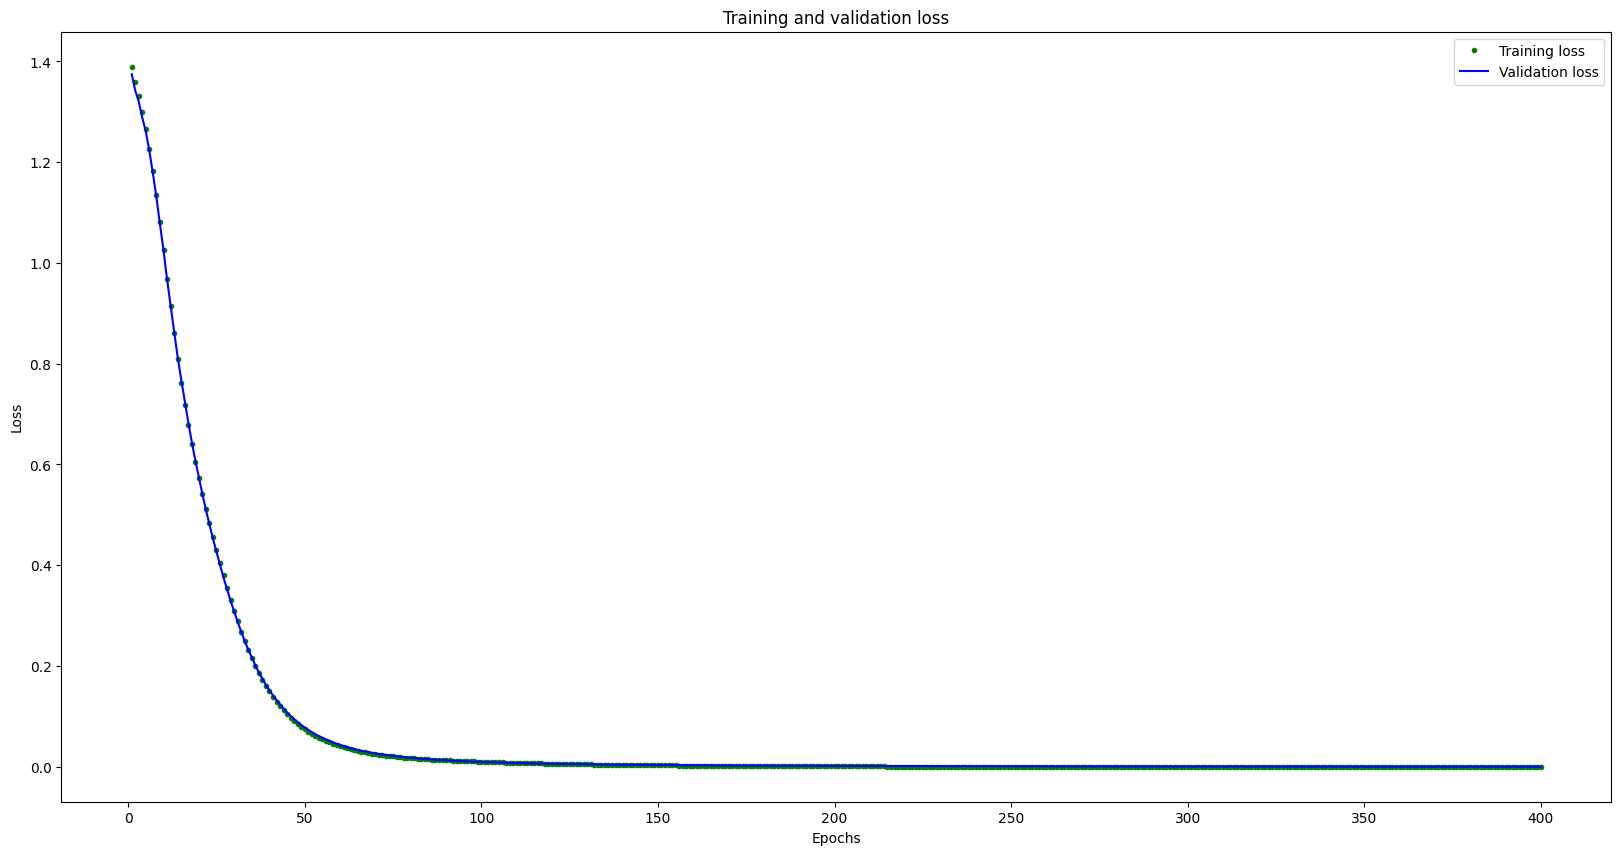

[20.0, 10.0]


In [6]:
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20,10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

# Run with Test Data

In [7]:
# use the model to predict the test inputs
predictions = model.predict(inputs_test)

# print the predictions and the expected ouputs
print("predictions =\n", np.round(predictions, decimals=3))
print("actual =\n", outputs_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
predictions =
 [[0.    1.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [1.    0.    0.    0.   ]
 [0.    1.    0.    0.   ]
 [1.    0.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    1.    0.    0.   ]
 [0.    0.    0.    1.   ]
 [0.    0.    0.    1.   ]
 [0.    0.    0.    1.   ]
 [1.    0.    0.    0.   ]
 [1.    0.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.944 0.056 0.   ]
 [1.    0.    0.    0.   ]
 [0.    0.    1.    0.   ]
 [0.    0.    1.    0.   ]]
actual =
 [[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]]


# Convert the Trained Model to Tensor Flow Lite

In [8]:
# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open("gesture_model.tflite", "wb").write(tflite_model)

import os
basic_model_size = os.path.getsize("gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)



Saved artifact at '/tmp/tmpkzqo6f_u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 18), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(1, 4), dtype=tf.float32, name=None)
Captures:
  133984821724752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133984821727248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133984821727440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133984821728208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133984821727824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133984821728784: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 6412 bytes


# Encode the Model in an Arduino Header File

In [ ]:
!echo "const unsigned char model[] = {" > /content/model.h
!cat gesture_model.tflite | xxd -i      >> /content/model.h
!echo "};"                              >> /content/model.h

import os
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 39,576 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.
